<a href="https://colab.research.google.com/github/Tauhid-Topu-007/sports-balls-multiclass-image-classification-Inceptionnet/blob/main/InceptionNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir ~/.kaggle

In [2]:
!cp kaggle.json ~/.kaggle/

In [3]:
!kaggle datasets download samuelcortinhas/sports-balls-multiclass-image-classification

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/sports-balls-multiclass-image-classification
License(s): CC0-1.0
100% 401M/401M [00:28<00:00, 14.6MB/s]



In [5]:
!unzip /content/sports-balls-multiclass-image-classification.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/cricket_ball/cricket_ball_182.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_183.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_185.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_186.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_187.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_189.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_19.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_190.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_191.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_192.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_195.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_196.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_199.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_200.jpg  
  inflating: /content/train/cricket_ball/cricket_ball_

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Rescaling

# For reproducibility
import numpy as np
import random
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

seed = 123

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

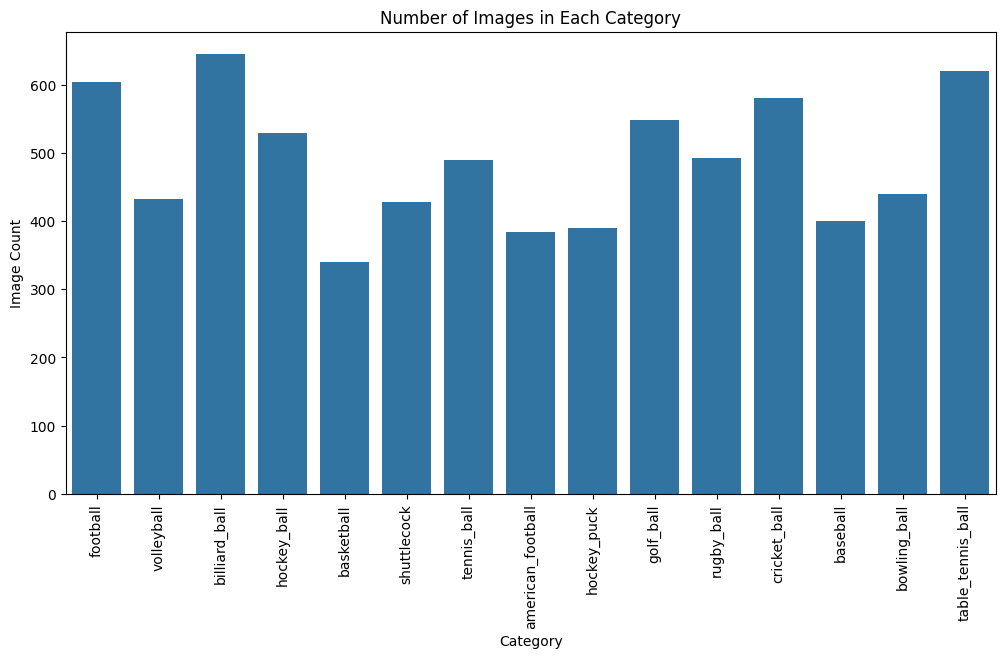

In [7]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Directory path (update with the correct path)
train_dir = "/content/train"

# Dictionary to store subdirectory names and file counts
data = {
    "Category": [],
    "Image Count": []
}

# Loop through each subdirectory in train_dir
for sub_dir in os.listdir(train_dir):
    sub_dir_path = os.path.join(train_dir, sub_dir)

    # Check if it is a directory
    if os.path.isdir(sub_dir_path):

        # Count number of image files
        num_files = len([
            f for f in os.listdir(sub_dir_path)
            if os.path.isfile(os.path.join(sub_dir_path, f))
        ])

        # Store the results
        data["Category"].append(sub_dir)
        data["Image Count"].append(num_files)

# Convert the data to a pandas DataFrame
df = pd.DataFrame(data)

# Create the bar plot using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x="Category", y="Image Count", data=df)
plt.xticks(rotation=90)
plt.title("Number of Images in Each Category")
plt.ylabel("Image Count")
plt.xlabel("Category")
plt.show()

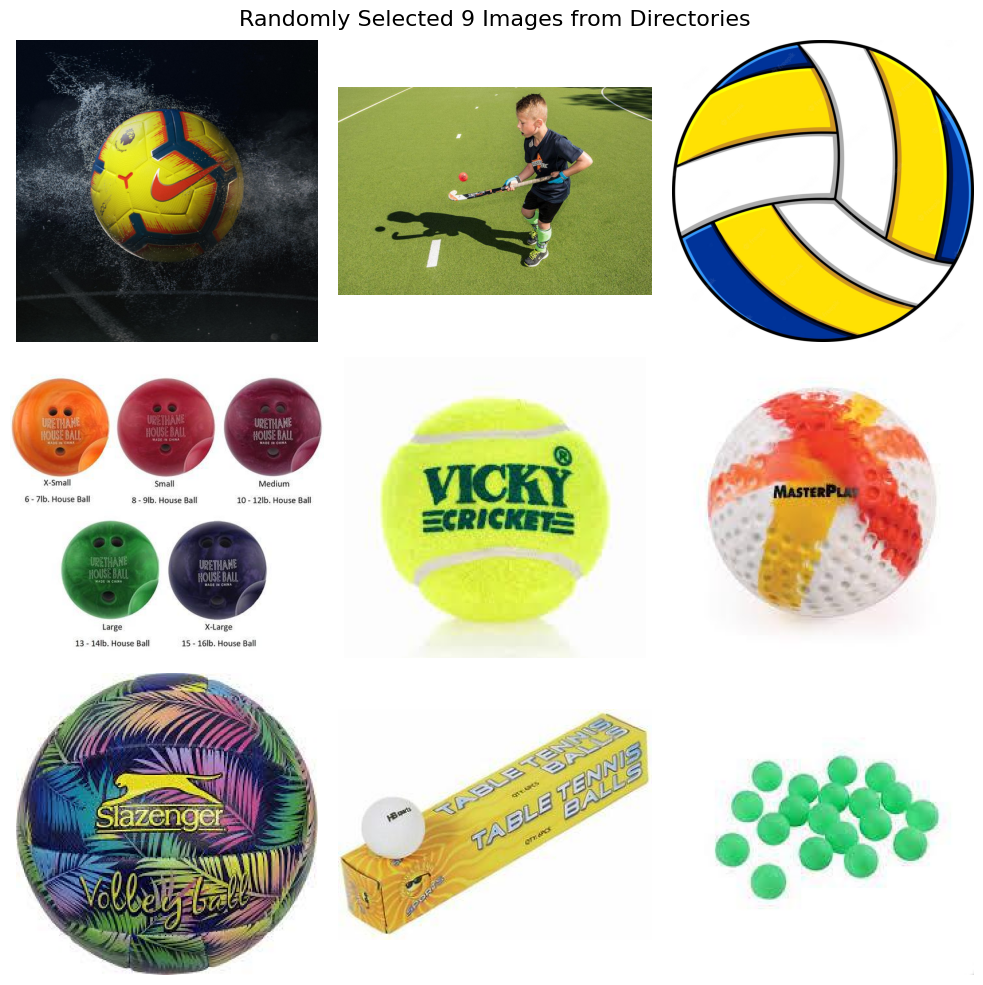

In [8]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Directory path (update with your correct path)
train_dir = "/content/train"

# List to store all image paths
all_images = []

# Loop through all subdirectories and collect file paths
for sub_dir in os.listdir(train_dir):
    sub_dir_path = os.path.join(train_dir, sub_dir)

    if os.path.isdir(sub_dir_path):
        all_images.extend(
            os.path.join(sub_dir_path, f)
            for f in os.listdir(sub_dir_path)
            if os.path.isfile(os.path.join(sub_dir_path, f))
        )

# Randomly select 9 images
random_images = random.sample(all_images, 9)

# Plotting the images in a 3x3 grid
plt.figure(figsize=(10, 10))
for i, image_path in enumerate(random_images):
    img = mpimg.imread(image_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")  # Turn off the axis

plt.suptitle("Randomly Selected 9 Images from Directories", fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

def inception_module(x,
                     filters_1x1,
                     filters_3x3_reduce, filters_3x3,
                     filters_5x5_reduce, filters_5x5,
                     filters_pool_proj):

    # 1×1 conv
    conv_1x1 = layers.Conv2D(filters_1x1, (1, 1),
                             padding='same', activation='relu')(x)

    # 3×3 conv branch
    conv_3x3_reduce = layers.Conv2D(filters_3x3_reduce, (1, 1),
                                    padding='same', activation='relu')(x)
    conv_3x3 = layers.Conv2D(filters_3x3, (3, 3),
                             padding='same', activation='relu')(conv_3x3_reduce)

    # 5×5 conv branch
    conv_5x5_reduce = layers.Conv2D(filters_5x5_reduce, (1, 1),
                                    padding='same', activation='relu')(x)
    conv_5x5 = layers.Conv2D(filters_5x5, (5, 5),
                             padding='same', activation='relu')(conv_5x5_reduce)

    # Max-pool + 1×1 conv
    pool_proj = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool_proj = layers.Conv2D(filters_pool_proj, (1, 1),
                              padding='same', activation='relu')(pool_proj)

    # Concatenate all branches
    output = layers.concatenate([conv_1x1, conv_3x3, conv_5x5, pool_proj], axis=-1)

    return output

In [10]:
def auxiliary_classifier(x, num_classes):
    # Average Pooling
    aux = layers.AveragePooling2D((5, 5), strides=(3, 3))(x)

    # 1×1 Convolution
    aux = layers.Conv2D(128, (1, 1), padding='same',
                        activation='relu')(aux)

    # Flatten
    aux = layers.Flatten()(aux)

    # Fully Connected Layer
    aux = layers.Dense(1024, activation='relu')(aux)

    # Dropout
    aux = layers.Dropout(0.7)(aux)

    # Output Softmax Layer
    aux = layers.Dense(num_classes, activation='softmax')(aux)

    return aux

In [17]:
# Build GoogLeNet (Inception v1)

def build_googlenet(input_shape, num_classes):
    input_layer = layers.Input(shape=input_shape)

    x=layers.Rescaling(1./255)(input_layer)
    # Initial layers
    x = layers.Conv2D(64, (7, 7), strides=(2, 2),
                      padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = layers.Conv2D(192, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Inception 3a & 3b
    x = inception_module(x, 64, 96, 128, 16, 32, 32)   # 3a
    x = inception_module(x, 128, 128, 192, 32, 96, 64) # 3b
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Inception 4a
    x = inception_module(x, 192, 96, 208, 16, 48, 64)

    # Auxiliary 1
    aux1 = auxiliary_classifier(x, num_classes)

    # Inception 4b–4e
    x = inception_module(x, 160, 112, 224, 24, 64, 64)  # 4b
    x = inception_module(x, 128, 128, 256, 24, 64, 64)  # 4c
    x = inception_module(x, 112, 144, 288, 32, 64, 64)  # 4d

    # Auxiliary 2
    aux2 = auxiliary_classifier(x, num_classes)

    x = inception_module(x, 256, 160, 320, 32, 128, 128) # 4e
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Inception 5a & 5b
    x = inception_module(x, 256, 160, 320, 32, 128, 128) # 5a
    x = inception_module(x, 384, 192, 384, 48, 128, 128) # 5b

    # Final layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    main_output = layers.Dense(num_classes, activation='softmax')(x)

    # Build model with 3 outputs
    model = models.Model(inputs=input_layer,
                         outputs=[main_output, aux1, aux2])
    return model

In [18]:
# Model parameters
input_shape = (224, 224, 3)   # ImageNet image size
num_classes = 15              # Number of classes for classification

# Build the model
googlenet = build_googlenet(input_shape, num_classes)

# Show model summary
googlenet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 112, 112,  │      9,472 │ rescaling[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 56, 56,    │          0 │ conv2d_58[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 56, 56,    │    110,784 │ max_pooling2d_13… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 28, 28,    │          0 │ conv2d_59[0][0]   │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 28, 28,    │     18,528 │ max_pooling2d_14… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 28, 28,    │      3,088 │ max_pooling2d_14… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 28, 28,    │          0 │ max_pooling2d_14… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 28, 28,    │     12,352 │ max_pooling2d_14… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 28, 28,    │    110,720 │ conv2d_61[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 28, 28,    │     12,832 │ conv2d_63[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 28, 28,    │      6,176 │ max_pooling2d_15… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 28, 28,    │          0 │ conv2d_60[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_62[0][0],  │
│                     │                   │            │ conv2d_64[0][0],  │
│                     │                   │            │ conv2d_65[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 28, 28,    │     32,896 │ concatenate_9[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_69 (Conv2D)  │ (None, 28, 28,    │      8,224 │ concatenate_9[0]… │
│                     │ 32)               │            │                 

 Total params: 10,345,245 (39.46 MB)

 Trainable params: 10,345,245 (39.46 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Set up directory and parameters
train_dir = "/content/train"
img_size = (224, 224)
batch_size = 32
num_classes = 15   # Update with your actual number of classes


In [14]:
train_dir = "/content/train"

In [20]:
# Load training and validation datasets
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)
# Prefetch for performance
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

Found 7328 files belonging to 15 classes.
Using 5863 files for training.
Found 7328 files belonging to 15 classes.
Using 1465 files for validation.


In [25]:
train_dataset = train_dataset.map(lambda x, y: (x, (y, y, y)))
validation_dataset = validation_dataset.map(lambda x, y: (x, (y, y, y)))

In [26]:
for images, labels in train_dataset.take(1):
    print("Label structure:", labels)

Label structure: (<tf.Tensor: shape=(32,), dtype=int32, numpy=
array([ 5,  7,  4,  3, 11,  8, 12,  6,  7,  2,  0,  5,  8,  9,  9,  8,  4,
        3, 12, 13,  5, 10,  8,  7,  7, 12,  5,  8, 12,  2, 14, 11],
      dtype=int32)>, <tf.Tensor: shape=(32,), dtype=int32, numpy=
array([ 5,  7,  4,  3, 11,  8, 12,  6,  7,  2,  0,  5,  8,  9,  9,  8,  4,
        3, 12, 13,  5, 10,  8,  7,  7, 12,  5,  8, 12,  2, 14, 11],
      dtype=int32)>, <tf.Tensor: shape=(32,), dtype=int32, numpy=
array([ 5,  7,  4,  3, 11,  8, 12,  6,  7,  2,  0,  5,  8,  9,  9,  8,  4,
        3, 12, 13,  5, 10,  8,  7,  7, 12,  5,  8, 12,  2, 14, 11],
      dtype=int32)>)


In [31]:
googlenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=[
        'sparse_categorical_crossentropy',
        'sparse_categorical_crossentropy',
        'sparse_categorical_crossentropy'
    ],
    metrics=[
        'accuracy',   # main classifier
        'accuracy',   # aux1
        'accuracy'    # aux2
    ]
)

In [32]:
history = googlenet.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 115s 364ms/step - dense_6_accuracy: 0.0856 - dense_6_loss: 2.7028 - dense_8_accuracy: 0.0890 - dense_8_loss: 2.7042 - dense_9_accuracy: 0.0826 - dense_9_loss: 2.7041 - loss: 8.1106 - val_dense_6_accuracy: 0.0976 - val_dense_6_loss: 2.6880 - val_dense_8_accuracy: 0.0915 - val_dense_8_loss: 2.6918 - val_dense_9_accuracy: 0.0846 - val_dense_9_loss: 2.6917 - val_loss: 8.0714
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 75s 184ms/step - dense_6_accuracy: 0.0996 - dense_6_loss: 2.6883 - dense_8_accuracy: 0.0923 - dense_8_loss: 2.6909 - dense_9_accuracy: 0.0855 - dense_9_loss: 2.6935 - loss: 8.0735 - val_dense_6_accuracy: 0.1188 - val_dense_6_loss: 2.6722 - val_dense_8_accuracy: 0.1140 - val_dense_8_loss: 2.6759 - val_dense_9_accuracy: 0.1195 - val_dense_9_loss: 2.6822 - val_loss: 8.0307
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 29s 158ms/step - dense_6_accuracy: 0.1165 - dense_6_loss: 2.6714 - dense_8_accuracy: 0.1148 - dense_8_loss: 2.6703 - dense_9_accuracy: 0

In [33]:
googlenet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 112, 112,  │      9,472 │ rescaling[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 56, 56,    │          0 │ conv2d_58[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 56, 56,    │    110,784 │ max_pooling2d_13… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 28, 28,    │          0 │ conv2d_59[0][0]   │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 28, 28,    │     18,528 │ max_pooling2d_14… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 28, 28,    │      3,088 │ max_pooling2d_14… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 28, 28,    │          0 │ max_pooling2d_14… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 28, 28,    │     12,352 │ max_pooling2d_14… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 28, 28,    │    110,720 │ conv2d_61[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 28, 28,    │     12,832 │ conv2d_63[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 28, 28,    │      6,176 │ max_pooling2d_15… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 28, 28,    │          0 │ conv2d_60[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_62[0][0],  │
│                     │                   │            │ conv2d_64[0][0],  │
│                     │                   │            │ conv2d_65[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 28, 28,    │     32,896 │ concatenate_9[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_69 (Conv2D)  │ (None, 28, 28,    │      8,224 │ concatenate_9[0]… │
│                     │ 32)               │            │                 

 Total params: 31,035,737 (118.39 MB)

 Trainable params: 10,345,245 (39.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,690,492 (78.93 MB)